In [ ]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/imdb-dataset-of-50k-movie-reviews
['IMDB Dataset.csv']


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Create Project Folder

In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/NLP_Sentiment_Project"

os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/dataset", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/models", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/tokenizer", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/history", exist_ok=True)

print("Folders Created")

Folders Created


Copy Dataset to Google Drive

In [ ]:
import shutil
import os

source = os.path.join(path, "IMDB Dataset.csv")
destination = f"{PROJECT_PATH}/dataset/IMDB Dataset.csv"

if not os.path.exists(destination):

    shutil.copy(source, destination)
    print("Dataset copied to Google Drive.")

else:

    print("Dataset already exists in Drive.")

Dataset copied to Google Drive.


Load Dataset

In [ ]:
import pandas as pd

dataset_path = "/content/drive/MyDrive/NLP_Sentiment_Project/dataset/IMDB Dataset.csv"

df = pd.read_csv(dataset_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Check Dataset

In [ ]:
print(df.shape)

print(df.info())

print(df.sentiment.value_counts())

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


Exploratory Data Analysis (EDA)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import string

from wordcloud import WordCloud

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sentiment Distribution

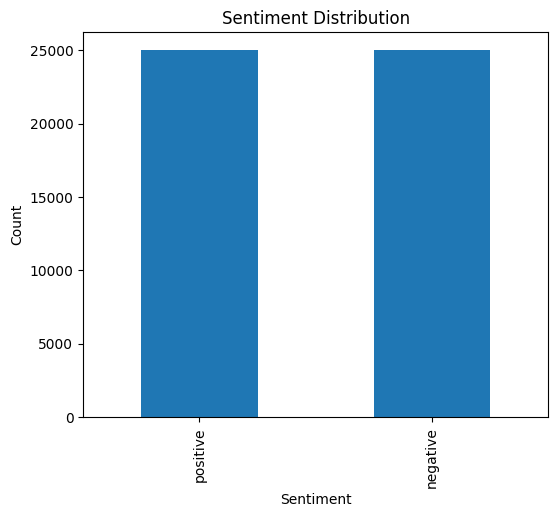

In [ ]:
plt.figure(figsize=(6,5))

df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

Review length

In [ ]:
df["review_length"] = df["review"].apply(
    lambda x: len(x.split())
)

df["review_length"].describe()

,review_length
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


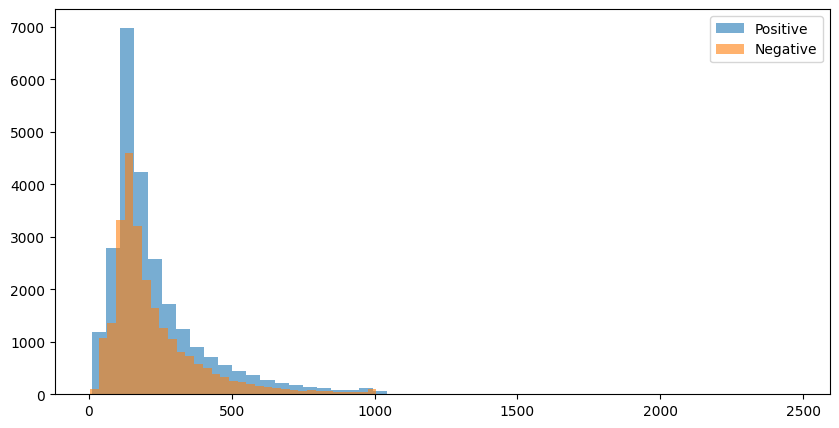

In [ ]:
positive = df[df.sentiment=="positive"]

negative = df[df.sentiment=="negative"]

plt.figure(figsize=(10,5))

plt.hist(
    positive.review_length,
    bins=50,
    alpha=0.6,
    label="Positive"
)

plt.hist(
    negative.review_length,
    bins=50,
    alpha=0.6,
    label="Negative"
)

plt.legend()

plt.show()

Word cloud

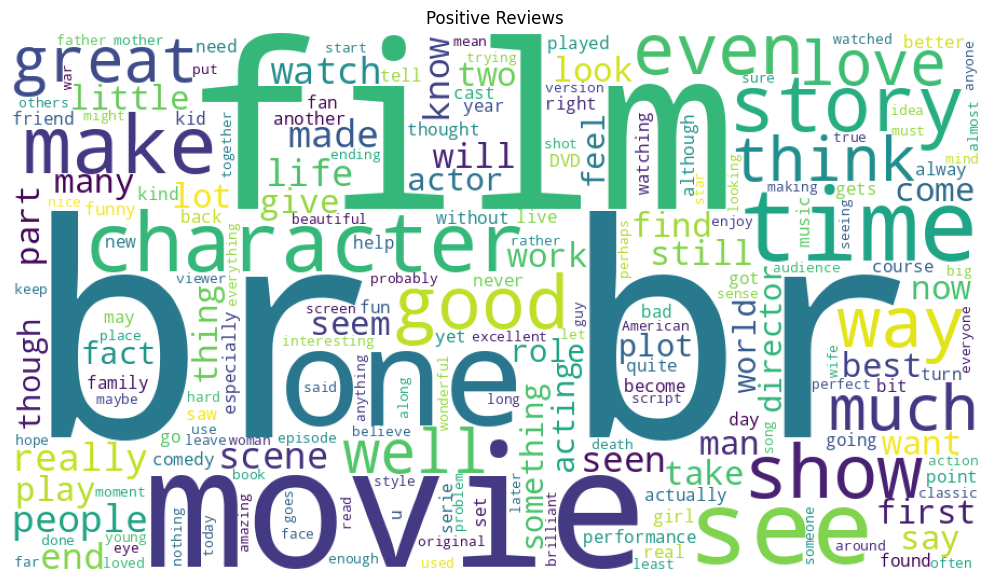

In [ ]:
positive_text = " ".join(
    df[df.sentiment=="positive"]["review"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews")

plt.show()

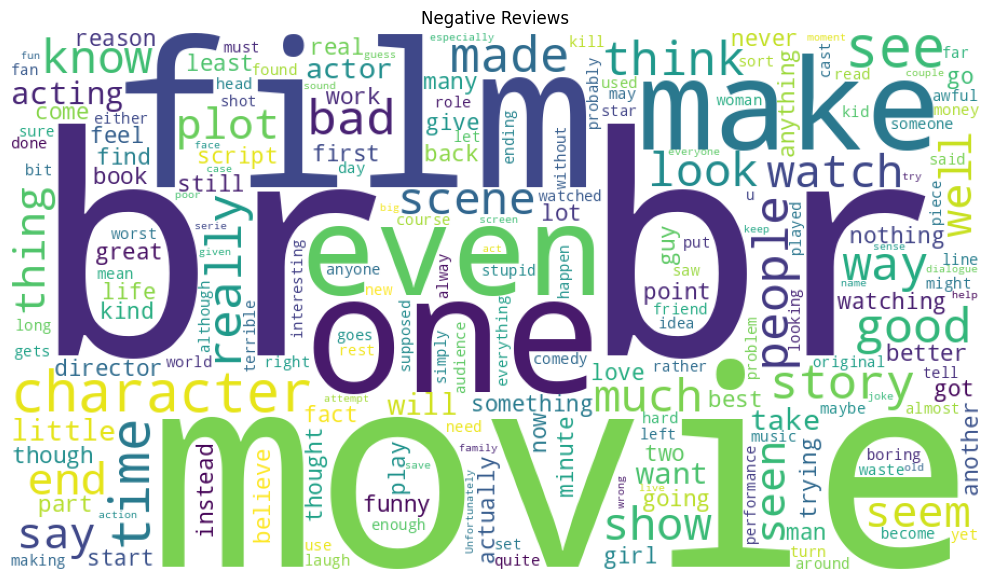

In [ ]:
negative_text = " ".join(
    df[df.sentiment=="negative"]["review"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews")

plt.show()

In [ ]:
display(df.head())

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


Text Preprocessing

In [ ]:
import re
import string
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

Text Cleaning Function

This function performs:

- Convert text to lowercase
- Remove HTML tags
- Remove URLs
- Remove punctuation
- Remove numbers
- Remove special characters
- Remove extra spaces
- Remove stopwords

In [ ]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove html tags
    text = re.sub(r'<.*?>', ' ', text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # keep only alphabets
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # remove stopwords
    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
# Apply cleaning
df["clean_review"] = df["review"].apply(clean_text)

In [ ]:
# Check cleaned reviews

display(df[
    ["review",
     "clean_review",
     "sentiment"]
].head())

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


In [ ]:
# Encode labels
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["sentiment"]
)

df[["sentiment","label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [ ]:
# Save label encoder
encoder_path = "/content/drive/MyDrive/NLP_Sentiment_Project/label_encoder.pkl"

with open(encoder_path, "wb") as f:
    pickle.dump(label_encoder, f)

print("Label Encoder Saved")

Label Encoder Saved


In [ ]:
X = df["clean_review"]

y = df["label"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

In [ ]:
print("Training :", X_train.shape)

print("Validation :", X_val.shape)

print("Testing :", X_test.shape)

Training : (40000,)
Validation : (5000,)
Testing : (5000,)


Step 8: Tokenization

We'll use:

- Vocabulary Size = 20,000
- OOV Token for unseen words

In [ ]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(

    num_words=VOCAB_SIZE,

    oov_token="<OOV>"
)

In [ ]:
# Fit tokenizer only on training data to avoid leakage
tokenizer.fit_on_texts(X_train)

In [ ]:
# save tokenizer
tokenizer_path = "/content/drive/MyDrive/NLP_Sentiment_Project/tokenizer/tokenizer.pkl"

with open(tokenizer_path, "wb") as f:

    pickle.dump(tokenizer, f)

print("Tokenizer Saved")

Tokenizer Saved


Convert Reviews into Sequences

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
print(X_train.iloc[0])

print()

print(X_train_seq[0])

caught little gem totally accident back revival theatre see two old silly scifi movies theatre packed full warning showed bunch scifi short spoofs get us mood somewhat amusing came within seconds audience hysterics biggest laugh came showed princess laia huge cinnamon buns instead hair head looks camera gives grim smile nods made even funnier gotta see chewabacca played looks like muppet extremely silly stupidbut couldnt stop laughing dialogue drowned laughter also know star wars pretty well even funnierthey deliberately poke fun dialogue really works audience definite

[901, 41, 1323, 332, 1466, 55, 8459, 1499, 11, 33, 77, 538, 765, 22, 1499, 3165, 265, 1625, 1071, 607, 765, 230, 7551, 15, 76, 1076, 528, 992, 259, 616, 1427, 195, 16683, 955, 324, 259, 1071, 2609, 1, 508, 1, 1, 189, 1026, 307, 176, 260, 290, 3081, 1688, 10089, 23, 7, 2513, 3035, 11, 1, 150, 176, 5, 4326, 445, 538, 1, 296, 471, 885, 291, 8335, 1967, 17, 39, 237, 1503, 86, 13, 7, 1, 4097, 9386, 143, 291, 10, 384, 195, 33

Padding

Neural networks require sequences of equal length.

In [ ]:
MAX_LENGTH = 200

X_train_pad = pad_sequences(

    X_train_seq,

    maxlen=MAX_LENGTH,

    padding="post",

    truncating="post"
)

X_val_pad = pad_sequences(

    X_val_seq,

    maxlen=MAX_LENGTH,

    padding="post",

    truncating="post"
)

X_test_pad = pad_sequences(

    X_test_seq,

    maxlen=MAX_LENGTH,

    padding="post",

    truncating="post"
)

In [ ]:
print(X_train_pad.shape)

print(X_val_pad.shape)

print(X_test_pad.shape)

(40000, 200)
(5000, 200)
(5000, 200)


Dataset loader

In [ ]:
import tensorflow as tf

In [ ]:
BATCH_SIZE = 64

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_pad, y_train.values)
)

- Shuffle → Better generalization
- Batch → Faster training
- Prefetch → Loads the next batch while the GPU processes the current one

```
# This is formatted as code
```



In [ ]:
train_dataset = (
    train_dataset
    .shuffle(buffer_size=len(X_train_pad))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
# validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val_pad, y_val.values)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test_pad, y_test.values)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
print("Training Dataset")
print(train_dataset)

print()

print("Validation Dataset")
print(val_dataset)

print()

print("Test Dataset")
print(test_dataset)

Training Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

Validation Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

Test Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


Verify One Batch

In [ ]:
for x_batch, y_batch in train_dataset.take(1):

    print("Input Shape :", x_batch.shape)

    print("Label Shape :", y_batch.shape)

    print()

    print("First Review Sequence:")

    print(x_batch[0])

    print()

    print("First Label:")

    print(y_batch[0])

Input Shape : (64, 200)
Label Shape : (64,)

First Review Sequence:
tf.Tensor(
[  116    49     2   251   368  3972  8317 10520  1144  1496 12028    16
   231   970    56 15379   644    36  1863   407   142 16869   407     9
    56  2769   644    36  9215    90     7     1    56    14  2024 15379
   116   827    63   139    83   644 15379    46   906    56   644    83
    15   407  1728   808   955  1448    44    31  3605     2    56   691
    23  1292   117   160    27   151    90    35  1671   497   473     2
  9215 15379    10    26   131   609     2    60    83  2769   691    48
     4   368    22    44    31     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0   

In [ ]:
print("Training Batches :", tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation Batches :", tf.data.experimental.cardinality(val_dataset).numpy())

print("Testing Batches :", tf.data.experimental.cardinality(test_dataset).numpy())

Training Batches : 625
Validation Batches : 79
Testing Batches : 79


Build and Train the Simple RNN Model

In [ ]:
import pickle
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import ModelCheckpoint

Define Hyperparameters

In [ ]:
VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
MAX_LENGTH = 200
RNN_UNITS = 128

EPOCHS = 10
LEARNING_RATE = 0.001

In [ ]:
rnn_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    SimpleRNN(
        units=RNN_UNITS,
        activation="tanh"
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model summary

In [ ]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/NLP_Sentiment_Project/models/rnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

Train the Model

In [ ]:
history_rnn = rnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/10
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4999 - loss: 0.7064 - precision: 0.4996 - recall: 0.5119
Epoch 1: val_accuracy improved from None to 0.49760, saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/rnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/rnn_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5002 - loss: 0.7002 - precision: 0.5002 - recall: 0.5094 - val_accuracy: 0.4976 - val_loss: 0.6931 - val_precision: 0.4988 - val_recall: 0.9892
Epoch 2/10
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4962 - loss: 0.6942 - precision: 0.4946 - recall: 0.4703
Epoch 2: val_accuracy improved from 0.49760 to 0.50040, saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/rnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/rnn_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4990 - loss

save training history

In [ ]:
with open(
    "/content/drive/MyDrive/NLP_Sentiment_Project/history/rnn_history.pkl",
    "wb"
) as file:

    pickle.dump(history_rnn.history, file)

print("Training history saved successfully.")

Training history saved successfully.


Evaluate on Test Data

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = rnn_model.evaluate(test_dataset)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.0000e+00 - recall: 0.0000e+00
Test Loss      : 0.6932
Test Accuracy  : 0.5000
Test Precision : 0.0000
Test Recall    : 0.0000


In [ ]:
#make predictions
predictions = rnn_model.predict(test_dataset)

predictions = (predictions > 0.5).astype(int)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
import numpy as np

# Predict probabilities
y_pred_prob = rnn_model.predict(test_dataset)

# Convert probabilities to class labels
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred[:10])

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
y_true = np.concatenate(
    [labels.numpy() for _, labels in test_dataset],
    axis=0
)

print(y_true[:10])

[0 1 1 0 0 0 0 0 1 0]


clasification report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67      2500
    Positive       0.00      0.00      0.00      2500

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.33      5000
weighted avg       0.25      0.50      0.33      5000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


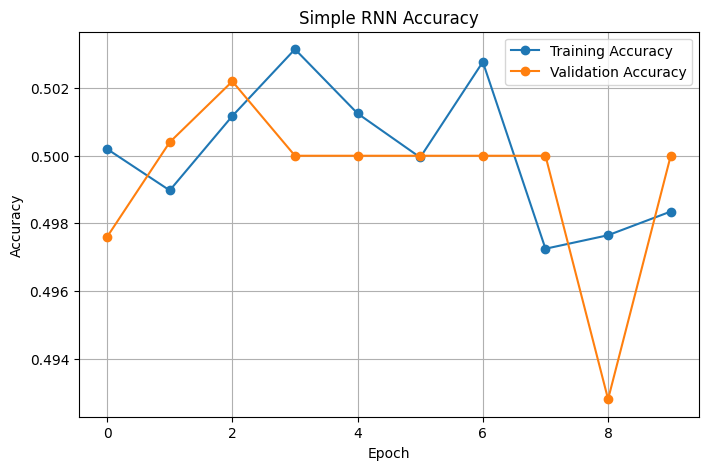

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Simple RNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.show()

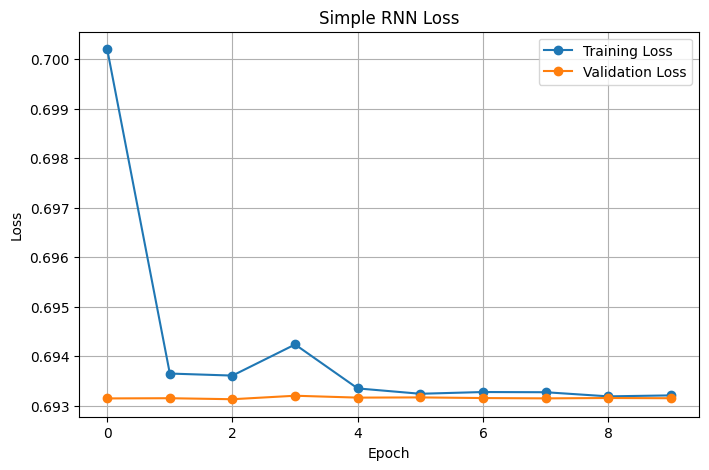

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Simple RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()

Build and Train LSTM Model

In [ ]:
import pickle
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
MAX_LENGTH = 200
LSTM_UNITS = 128

EPOCHS = 10
LEARNING_RATE = 0.001

In [ ]:
lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    LSTM(
        units=LSTM_UNITS,
        activation="tanh"
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
lstm_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]

)

In [ ]:
checkpoint = ModelCheckpoint(

    "/content/drive/MyDrive/NLP_Sentiment_Project/models/lstm_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [ ]:
history_lstm = lstm_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=[checkpoint],

    verbose=1

)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5021 - loss: 0.6941 - precision: 0.5044 - recall: 0.5819
Epoch 1: val_accuracy improved from None to 0.50900, saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/lstm_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.5080 - loss: 0.6946 - precision: 0.5084 - recall: 0.4836 - val_accuracy: 0.5090 - val_loss: 0.6917 - val_precision: 0.5049 - val_recall: 0.9260
Epoch 2/10
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5353 - loss: 0.6805 - precision: 0.5391 - recall: 0.4736
Epoch 2: val_accuracy improved from 0.50900 to 0.52280, saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/lstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP_Sentiment_Project/models/lstm_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5334 - 

In [ ]:
with open(
    "/content/drive/MyDrive/NLP_Sentiment_Project/history/lstm_history.pkl",
    "wb"
) as file:

    pickle.dump(history_lstm.history, file)

print("LSTM history saved successfully.")

LSTM history saved successfully.


In [ ]:
test_loss, test_accuracy, test_precision, test_recall = lstm_model.evaluate(test_dataset)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8726 - loss: 0.6636 - precision: 0.8730 - recall: 0.8720
Test Loss      : 0.6636
Test Accuracy  : 0.8726
Test Precision : 0.8730
Test Recall    : 0.8720


In [ ]:
import numpy as np

y_pred_prob = lstm_model.predict(test_dataset)

y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

y_true = np.concatenate(
    [labels.numpy() for _, labels in test_dataset],
    axis=0
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      2500
    Positive       0.87      0.87      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



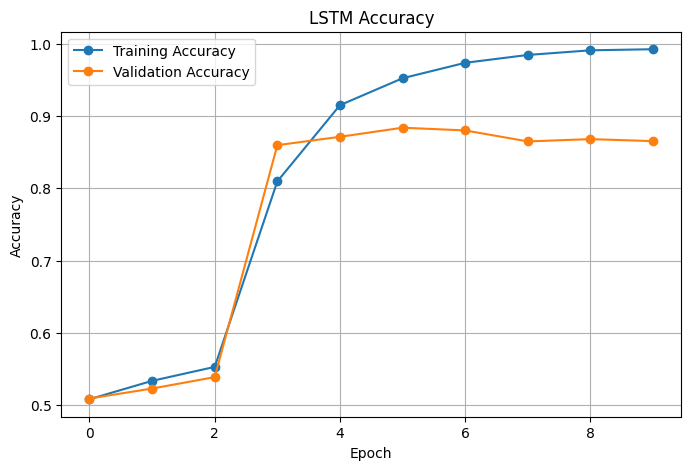

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.show()

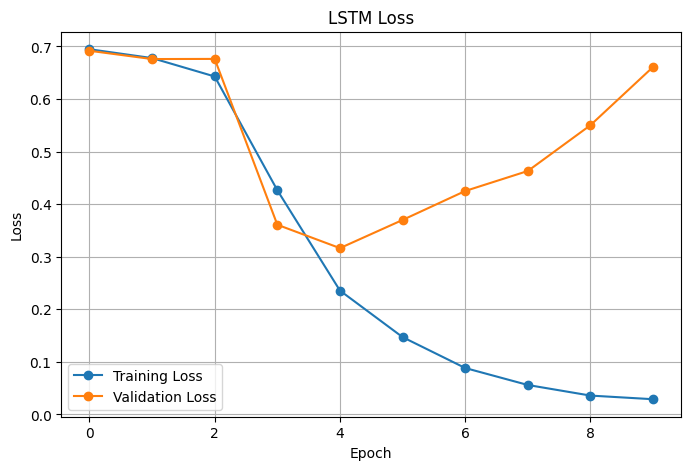

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
lstm_model.save(
    "/content/drive/MyDrive/NLP_Sentiment_Project/models/lstm_model.keras"
)

print("LSTM model saved successfully.")

LSTM model saved successfully.
